# Matched 7D-versus-8D ablation and scale sensitivity

This paired analysis isolates the effect of releasing `c_ctx2th`. Narrower 7D
marginals are not automatically better: fixing a difficult parameter may
remove an honest ridge. The ablation asks whether 8D adds mechanistic
completeness without unacceptable miscalibration.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "S4_sbi").exists() else cwd.parent.parent
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "figure10_8d_7d"
assert os.environ.get("CONDA_DEFAULT_ENV") == "neurolib"
print("environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("python:", sys.executable)
print("results:", RESULTS)

environment: neurolib
python: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
results: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d


,track,scale,members,best_validation_loss_mean,joint_rank_ks_statistic,joint_rank_ks_pvalue,clear_sbc_issues,recovery_improvement_fraction,median_normalized_posterior_sd,training_runtime_s,status
0,8d,8192,1,-7.107405,0.120070,2.538793e-13,4.0,0.398368,0.701215,82.325693,completed
1,7d,8192,1,-6.718251,0.123618,4.263601e-14,5.0,0.450241,0.712590,66.529504,completed
2,8d,32768,5,-8.935103,0.225012,4.914557e-46,3.0,0.430475,0.635710,1337.924536,completed
3,7d,32768,5,-9.636946,0.211778,8.893435e-41,3.0,0.502850,0.568156,13768.542388,completed
4,8d,131072,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not run: preregistered hardware limitation
5,7d,131072,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not run: preregistered hardware limitation
6,8d,524288,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not run: preregistered hardware limitation
7,7d,524288,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not run: preregistered hardware limitation
8,8d,1000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not run: preregistered hardware limitation
9,7d,1000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not run: preregistered hardware limitation


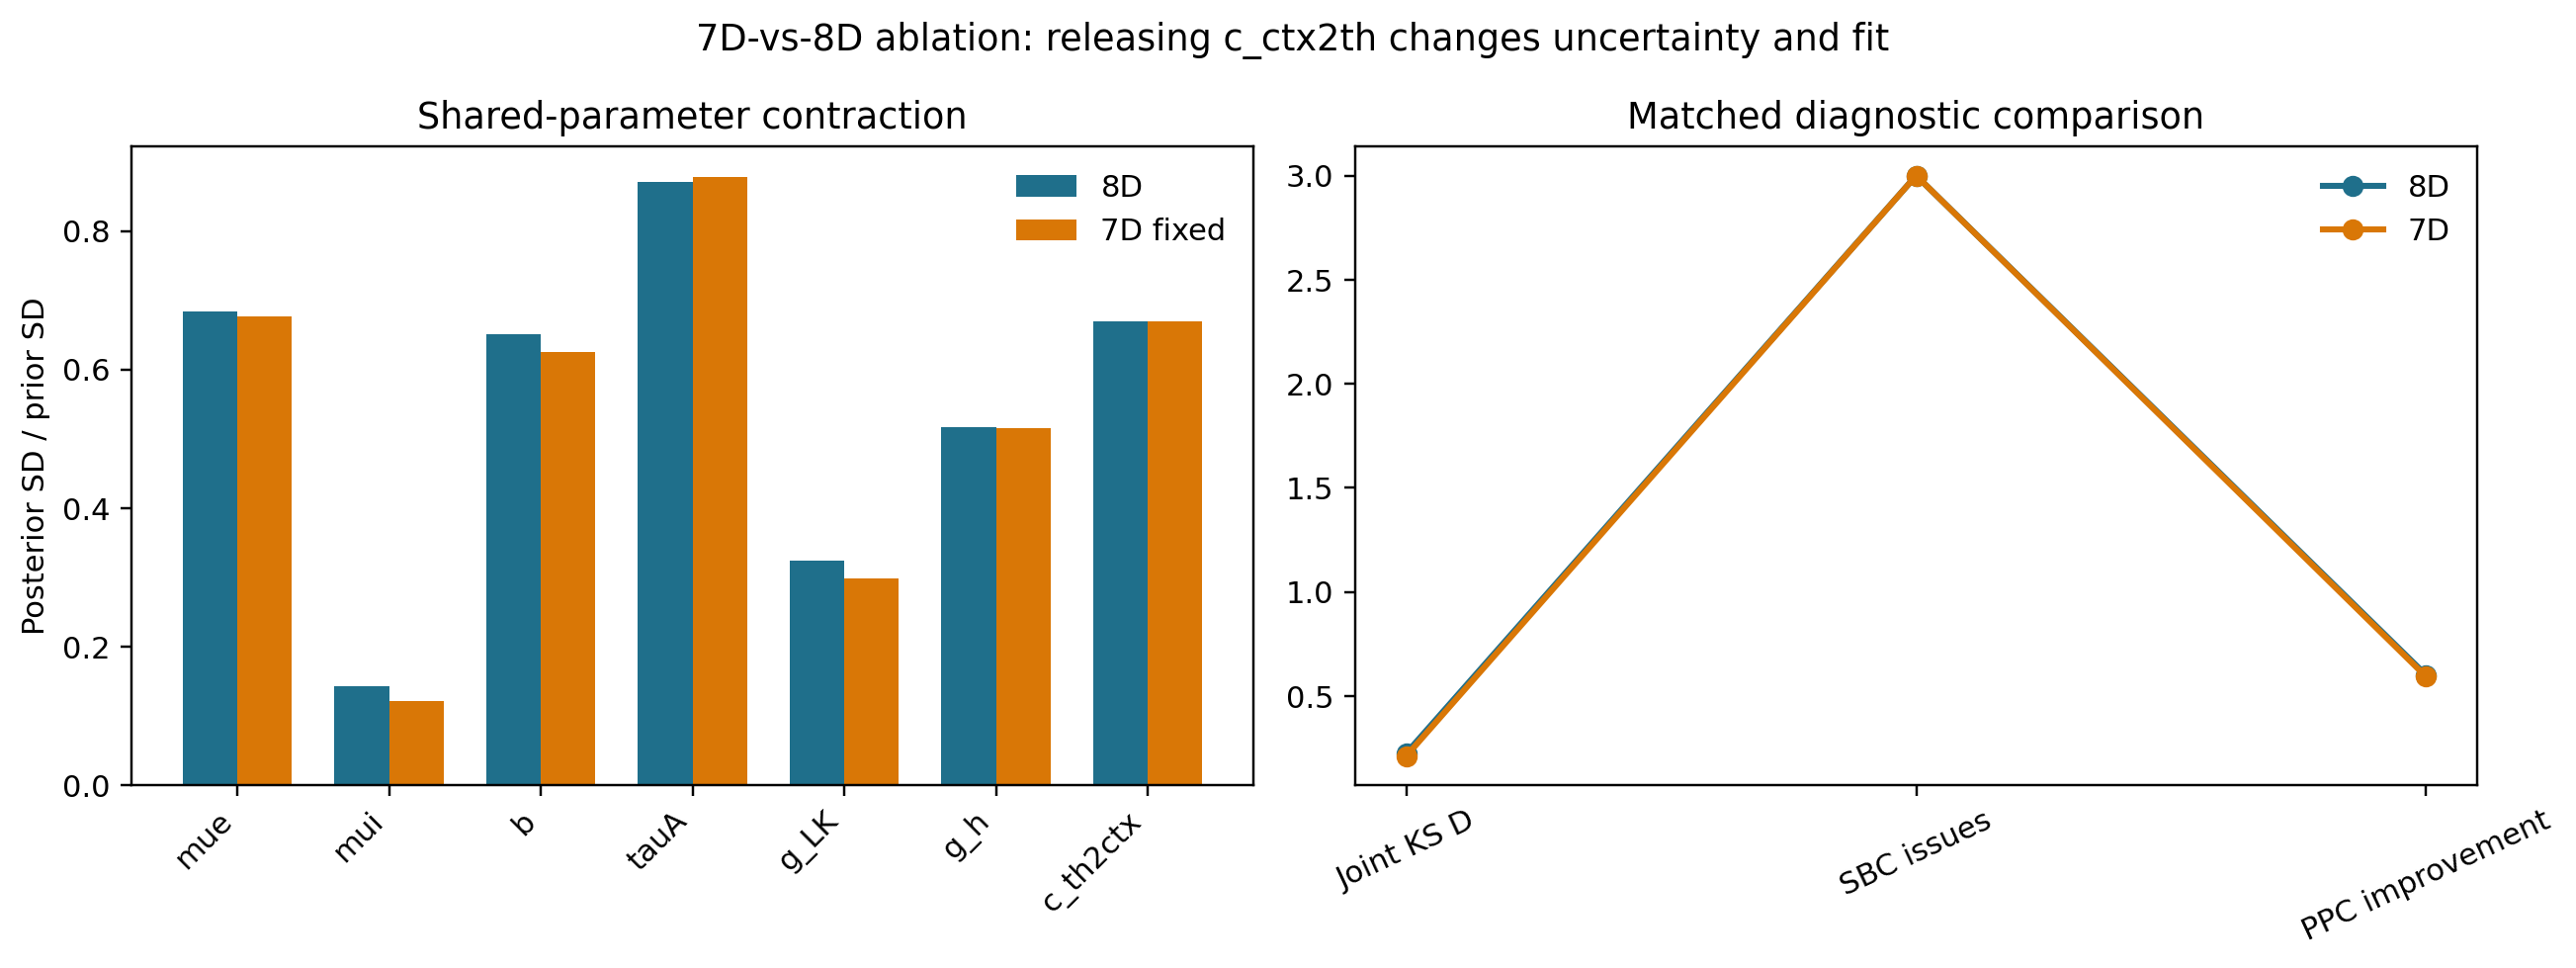

In [2]:
scale = pd.read_csv(RESULTS / "diagnostics" / "scale_sensitivity.csv")
display(scale)
display(Image(filename=str(RESULTS / "figures" / "figure10_7d_vs_8d_ablation.png")))

## Interpretation boundary

Only 8,192 and 32,768 are measured scales. Rows for 131,072 through 3,000,000
are explicit `not run` records, not extrapolated scientific results. Therefore
the experiment can identify changes over this limited ladder but cannot claim
exact replication of the official three-million-simulation regime.